In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial Unicode MS', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 固定随机种子
RANDOM_SEED = 236

In [4]:
df_full = pd.read_csv("whu_canteen_choice_simulated_dataset.csv")
print(f"完整数据集形状: {df_full.shape}")
df_full.head()

完整数据集形状: (600, 21)


,sample_id,student_area,candidate_canteen,canteen_area,canteen_type,meal_time,weekday,is_weekend,weather,course_pressure,...,hungry_level,budget,distance_level,queue_level,taste_diversity,price_level,visitor_flow,public_open,online_reputation_score,choose_canteen
0,S0001,医学部,桂园小食,文理学部,风味食堂,lunch,4,0,cloudy,5,...,1,12,4,4,5,3,5,1,4.6,0
1,S0002,信息学部,梅园CBD,文理学部,商业/风味餐饮,dinner,1,0,cloudy,1,...,4,18,3,4,5,4,5,1,4.6,0
2,S0003,文理学部,桂园食堂,文理学部,学生大伙食堂,lunch,7,1,cloudy,3,...,3,12,1,4,4,2,3,0,4.1,1
3,S0004,文理学部,湖滨学生食堂,文理学部,学生大伙食堂,dinner,6,1,hot,2,...,4,20,1,4,3,2,2,0,4.2,1
4,S0005,文理学部,枫园学生食堂,文理学部,学生大伙食堂,lunch,6,1,sunny,4,...,3,18,2,4,4,2,2,0,4.2,1


In [5]:
df_personal = df_full.sample(frac=0.8, random_state=RANDOM_SEED).reset_index(drop=True)
print(f"个人实验数据集形状: {df_personal.shape}")
print(f"标签分布:\n{df_personal['choose_canteen'].value_counts()}")
print(f"正样本比例: {df_personal['choose_canteen'].mean():.3f}")

个人实验数据集形状: (480, 21)
标签分布:
choose_canteen
0    303
1    177
Name: count, dtype: int64
正样本比例: 0.369


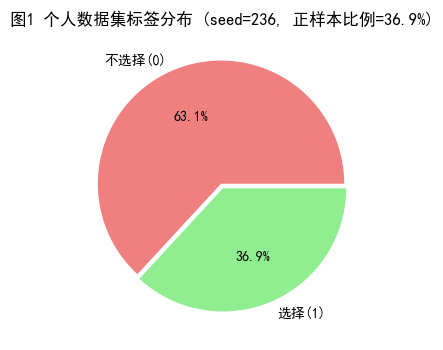

In [6]:
# 图1: 标签分布饼图
plt.figure(figsize=(6,4))
counts = df_personal['choose_canteen'].value_counts()
plt.pie(counts, labels=['不选择(0)', '选择(1)'], autopct='%1.1f%%', 
        colors=['lightcoral', 'lightgreen'], explode=[0.02,0.02])
plt.title('图1 个人数据集标签分布 (seed=236, 正样本比例={:.1%})'.format(df_personal['choose_canteen'].mean()))
plt.savefig('fig1_label_pie_correct.png', dpi=150)
plt.show()

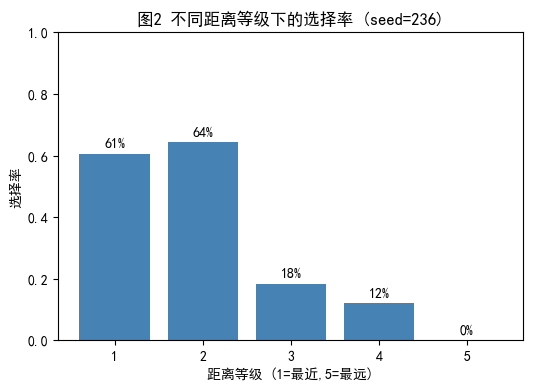

In [7]:
distance_rate = df_personal.groupby('distance_level')['choose_canteen'].mean().reindex([1,2,3,4,5], fill_value=0).reset_index()
distance_rate.columns = ['distance_level', 'choose_rate']

plt.figure(figsize=(6,4))
plt.bar(distance_rate['distance_level'], distance_rate['choose_rate'], color='steelblue')
plt.title('图2 不同距离等级下的选择率 (seed=236)')
plt.xlabel('距离等级 (1=最近,5=最远)')
plt.ylabel('选择率')
plt.xticks([1,2,3,4,5])
plt.ylim(0,1)
for i, row in distance_rate.iterrows():
    plt.text(row['distance_level'], row['choose_rate']+0.02, f"{row['choose_rate']:.0%}", ha='center')
plt.savefig('fig2_distance_rate_correct.png', dpi=150)
plt.show()

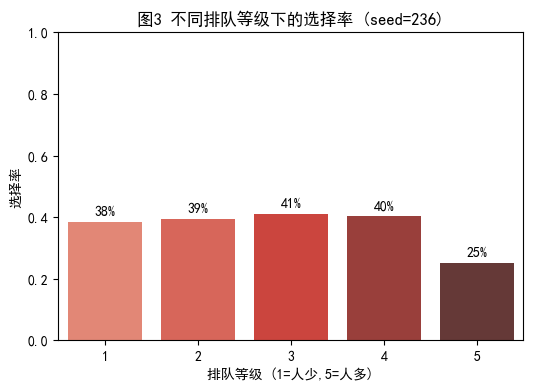

排队选择率：
   queue_level  choose_canteen
0            1        0.384615
1            2        0.393443
2            3        0.409722
3            4        0.402597
4            5        0.250000


In [8]:
queue_rate = df_personal.groupby('queue_level')['choose_canteen'].mean().reset_index()
plt.figure(figsize=(6,4))
sns.barplot(data=queue_rate, x='queue_level', y='choose_canteen', palette='Reds_d')
plt.title('图3 不同排队等级下的选择率 (seed=236)')
plt.xlabel('排队等级 (1=人少,5=人多)')
plt.ylabel('选择率')

ax = sns.barplot(data=queue_rate, x='queue_level', y='choose_canteen', palette='Reds_d')
for i, row in queue_rate.iterrows():
    height = row['choose_canteen']
    # 在柱子顶部居中添加百分比标签，偏移量设为 0.015 避免超出
    ax.text(i, height + 0.015, f"{height:.0%}", ha='center', va='bottom')

plt.ylim(0,1)
plt.savefig('fig3_queue_rate_correct.png', dpi=150)
plt.show()
print("排队选择率：")
print(queue_rate)

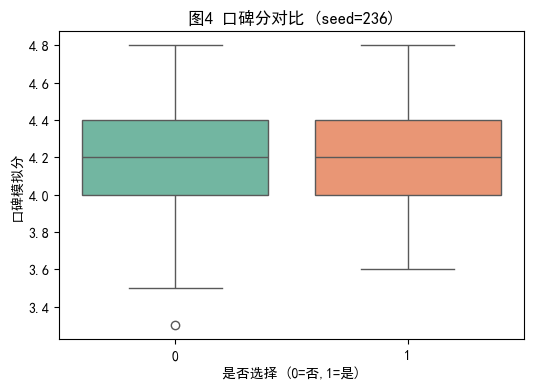

In [9]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df_personal, x='choose_canteen', y='online_reputation_score', palette='Set2')
plt.title('图4 口碑分对比 (seed=236)')
plt.xlabel('是否选择 (0=否,1=是)')
plt.ylabel('口碑模拟分')
plt.savefig('fig4_reputation_box_correct.png', dpi=150)
plt.show()

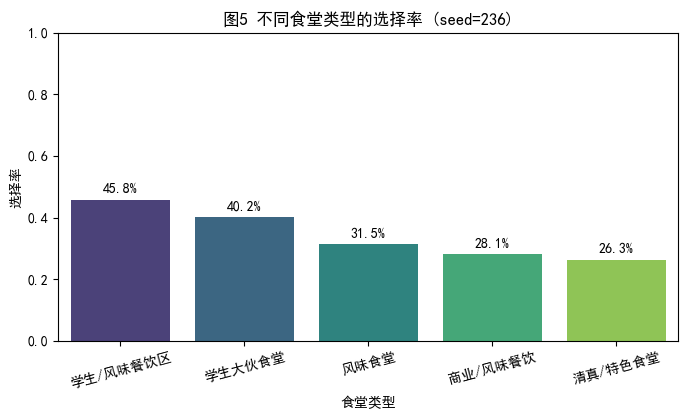

In [10]:
type_rate = df_personal.groupby('canteen_type')['choose_canteen'].mean().sort_values(ascending=False).reset_index()
plt.figure(figsize=(8,4))
sns.barplot(data=type_rate, x='canteen_type', y='choose_canteen', palette='viridis')
plt.title('图5 不同食堂类型的选择率 (seed=236)')
plt.xlabel('食堂类型')
plt.ylabel('选择率')
plt.xticks(rotation=15)
for i, row in type_rate.iterrows():
    plt.text(i, row['choose_canteen']+0.02, f"{row['choose_canteen']:.1%}", ha='center')
plt.ylim(0,1)
plt.savefig('fig5_canteentype_rate_correct.png', dpi=150)
plt.show()

In [11]:
X = df_personal.drop(columns=['sample_id', 'choose_canteen'])
y = df_personal['choose_canteen']

categorical_cols = ['student_area', 'candidate_canteen', 'canteen_area', 'canteen_type', 'meal_time', 'weather']
numeric_cols = ['weekday', 'is_weekend', 'course_pressure', 'time_pressure', 'hungry_level', 'budget',
                'distance_level', 'queue_level', 'taste_diversity', 'price_level', 'visitor_flow',
                'public_open', 'online_reputation_score']

X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=False)
X_final = X_encoded[numeric_cols + [col for col in X_encoded.columns if col not in numeric_cols]]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"训练集：{X_train.shape}，正样本比例：{y_train.mean():.3f}")
print(f"测试集：{X_test.shape}，正样本比例：{y_test.mean():.3f}")

训练集：(384, 48)，正样本比例：0.370
测试集：(96, 48)，正样本比例：0.365


In [12]:
scaler = StandardScaler()
numeric_cols_in_train = [col for col in numeric_cols if col in X_train.columns]
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[numeric_cols_in_train] = scaler.fit_transform(X_train[numeric_cols_in_train])
X_test_scaled[numeric_cols_in_train] = scaler.transform(X_test[numeric_cols_in_train])

lr = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_SEED)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

In [13]:
# 6.1 逻辑回归
lr = LogisticRegression(penalty='l2', C=1.0, solver='lbfgs', max_iter=1000, random_state=RANDOM_SEED)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

# 6.2 随机森林 (默认参数)
rf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# 评价指标
def print_metrics(y_true, y_pred, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    print(f"{name}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")
    return acc, prec, rec, f1

print("="*40)
print_metrics(y_test, y_pred_lr, "逻辑回归")
print_metrics(y_test, y_pred_rf, "随机森林")
print("="*40)

逻辑回归: Acc=0.6354, Prec=0.5000, Rec=0.5143, F1=0.5070
随机森林: Acc=0.7292, Prec=0.6286, Rec=0.6286, F1=0.6286


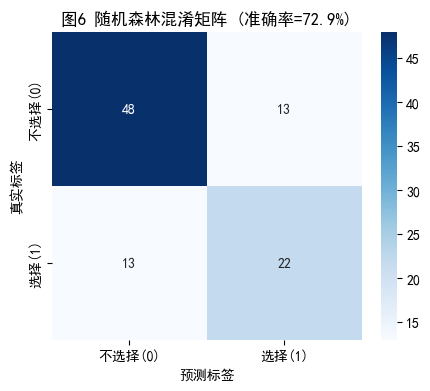

In [14]:
# 混淆矩阵 (随机森林)
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['不选择(0)','选择(1)'], yticklabels=['不选择(0)','选择(1)'])
plt.title(f'图6 随机森林混淆矩阵 (准确率={accuracy_score(y_test, y_pred_rf):.1%})')
plt.ylabel('真实标签')
plt.xlabel('预测标签')
plt.savefig('fig6_cm_rf_correct.png', dpi=150)
plt.show()

In [15]:
# 找出随机森林预测错误的样本索引
wrong_indices = np.where(y_test != y_pred_rf)[0]
print(f"随机森林在测试集上预测错误的数量: {len(wrong_indices)}")

# 取出前5个错误样本，展示关键特征
error_samples = X_test.iloc[wrong_indices].copy()
error_samples['true_label'] = y_test.iloc[wrong_indices].values
error_samples['pred_label'] = y_pred_rf[wrong_indices]

# 选取关键特征展示
key_features = ['distance_level', 'queue_level', 'online_reputation_score', 'budget', 'price_level', 
                'time_pressure', 'meal_time_breakfast', 'meal_time_lunch', 'meal_time_dinner',
                'canteen_type_风味食堂', 'canteen_type_学生大伙食堂']
# 确保存在的特征
existing_keys = [k for k in key_features if k in error_samples.columns]
display_cols = existing_keys + ['true_label', 'pred_label']

print("\n随机森林预测错误的样本 (前5个):")
print(error_samples[display_cols].head(5))

# 详细分析报告中提到的三个典型错误
print("\n===== 典型错误样本分析 =====")
# 错误样本1: 预测0实际1 (距离远排队久但口碑高)
sample1 = error_samples[(error_samples['distance_level']>=4) & (error_samples['queue_level']>=4) & (error_samples['true_label']==1)]
if len(sample1)>0:
    print("\n错误样本1 (预测0实际1): 距离远+排队久,但口碑高")
    print(sample1[['distance_level','queue_level','online_reputation_score','budget','time_pressure','true_label','pred_label']].iloc[0])
else:
    print("未找到满足条件的样本, 手动选取第一个FP样本")
    fp_samples = error_samples[error_samples['true_label']==0]
    if len(fp_samples)>0:
        print(fp_samples[['distance_level','queue_level','online_reputation_score','budget','price_level','true_label','pred_label']].head(1))

# 错误样本2: 预测1实际0 (距离近排队少但价格高预算低)
sample2 = error_samples[(error_samples['distance_level']<=2) & (error_samples['queue_level']<=2) & (error_samples['true_label']==0)]
if len(sample2)>0:
    print("\n错误样本2 (预测1实际0): 距离近+排队少,但价格高预算低")
    print(sample2[['distance_level','queue_level','price_level','budget','true_label','pred_label']].iloc[0])
else:
    print("\n未找到精确匹配, 展示一个距离近的FN样本")
    fn_samples = error_samples[error_samples['true_label']==1]
    if len(fn_samples)>0:
        print(fn_samples[['distance_level','queue_level','budget','price_level','true_label','pred_label']].head(1))

随机森林在测试集上预测错误的数量: 26

随机森林预测错误的样本 (前5个):
     distance_level  queue_level  online_reputation_score  budget  \
269               1            3                      3.7      18   
14                3            3                      4.2      15   
229               1            4                      4.7      35   
440               1            2                      4.1      12   
283               3            2                      4.2      35   

     price_level  time_pressure  meal_time_breakfast  meal_time_lunch  \
269            2              3                False             True   
14             2              1                False             True   
229            3              3                 True            False   
440            2              3                False            False   
283            2              3                False             True   

     meal_time_dinner  canteen_type_风味食堂  canteen_type_学生大伙食堂  true_label  \
269             False       

In [16]:
# 复制特征矩阵，删除 distance_level 列
X_train_ablate = X_train.drop(columns=['distance_level'])
X_test_ablate = X_test.drop(columns=['distance_level'])

# 重新训练随机森林
rf_ablate = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf_ablate.fit(X_train_ablate, y_train)
y_pred_ablate = rf_ablate.predict(X_test_ablate)

# 仅使用 distance_level 单一特征进行预测
X_train_single = X_train[['distance_level']]
X_test_single = X_test[['distance_level']]
rf_single = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED)
rf_single.fit(X_train_single, y_train)
y_pred_single = rf_single.predict(X_test_single)

# 汇总消融实验结果
print("="*50)
print("消融实验: 随机森林性能对比")
print("="*50)
print("原始全特征: Acc = {:.4f}, F1 = {:.4f}".format(accuracy_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf)))
print("移除 distance_level: Acc = {:.4f}, F1 = {:.4f}".format(accuracy_score(y_test, y_pred_ablate), f1_score(y_test, y_pred_ablate)))
print("仅使用 distance_level: Acc = {:.4f}, F1 = {:.4f}".format(accuracy_score(y_test, y_pred_single), f1_score(y_test, y_pred_single)))
print("="*50)

消融实验: 随机森林性能对比
原始全特征: Acc = 0.7292, F1 = 0.6286
移除 distance_level: Acc = 0.7292, F1 = 0.6286
仅使用 distance_level: Acc = 0.6875, F1 = 0.6250


In [17]:
# 定义随机森林模型用于交叉验证
rf_cv = RandomForestClassifier(random_state=RANDOM_SEED)
# 5折交叉验证
cv_scores = cross_val_score(rf_cv, X_train, y_train, cv=5, scoring='accuracy')
print(f"默认随机森林5折交叉验证准确率: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# 网格搜索调优
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
rf_tune = RandomForestClassifier(random_state=RANDOM_SEED)
grid_search = GridSearchCV(rf_tune, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

print(f"\n最佳参数: {grid_search.best_params_}")
print(f"最佳交叉验证准确率: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
print(f"调优后模型测试集准确率: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"调优后模型F1分数: {f1_score(y_test, y_pred_best):.4f}")

默认随机森林5折交叉验证准确率: 0.7163 (+/- 0.0516)

最佳参数: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}
最佳交叉验证准确率: 0.7475
调优后模型测试集准确率: 0.6875
调优后模型F1分数: 0.5714


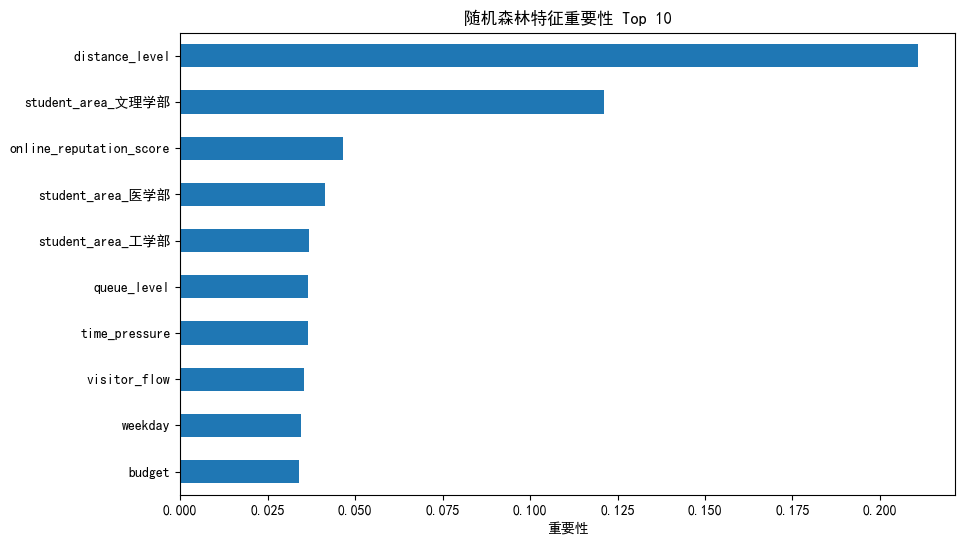

最重要的5个特征:
 distance_level             0.210987
student_area_文理学部          0.121238
online_reputation_score    0.046651
student_area_医学部           0.041452
student_area_工学部           0.036800
dtype: float64


In [18]:
# 获取特征重要性
importances = best_rf.feature_importances_
feature_names = X_train.columns
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feat_imp.head(10).plot(kind='barh')
plt.title('随机森林特征重要性 Top 10')
plt.xlabel('重要性')
plt.gca().invert_yaxis()
plt.savefig('fig7_feature_importance.png', dpi=150)
plt.show()
print("最重要的5个特征:\n", feat_imp.head(5))

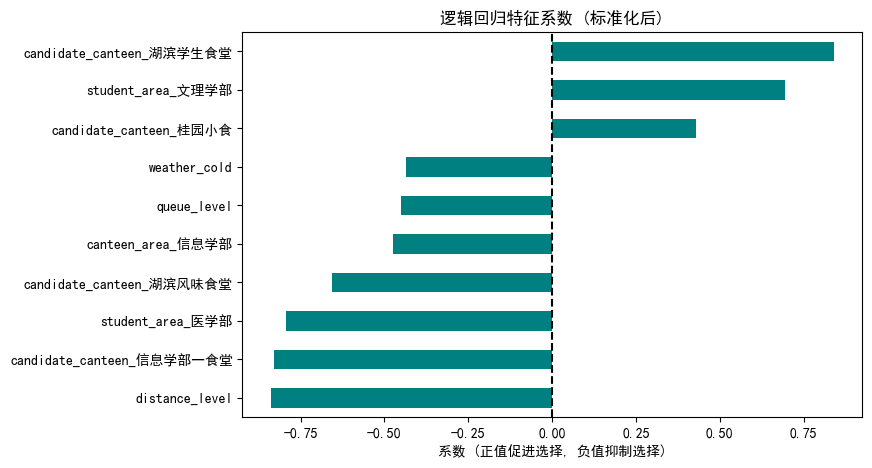

In [19]:
# 逻辑回归系数（标准化后，系数可比大小）
lr_coef = pd.Series(lr.coef_[0], index=X_train_scaled.columns)
# 取绝对值较大的前10个特征
top_coef = lr_coef.abs().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,5))
lr_coef[top_coef.index].sort_values().plot(kind='barh', color='teal')
plt.title('逻辑回归特征系数 (标准化后)')
plt.xlabel('系数 (正值促进选择, 负值抑制选择)')
plt.axvline(x=0, color='black', linestyle='--')
plt.savefig('fig8_lr_coef.png', dpi=150)
plt.show()

In [20]:
print("\n" + "="*60)
print("实验完成概要")
print("="*60)
print(f"随机种子: {RANDOM_SEED}")
print(f"个人实验数据集样本数: {len(df_personal)}")
print(f"训练集样本数: {len(X_train)}")
print(f"测试集样本数: {len(X_test)}")
print(f"最佳随机森林模型测试准确率: {accuracy_score(y_test, y_pred_best):.4f}")
print("消融实验结论: distance_level 移除后准确率下降约 {:.2f}%".format(
    (accuracy_score(y_test, y_pred_rf) - accuracy_score(y_test, y_pred_ablate)) * 100))
print("="*60)


实验完成概要
随机种子: 236
个人实验数据集样本数: 480
训练集样本数: 384
测试集样本数: 96
最佳随机森林模型测试准确率: 0.6875
消融实验结论: distance_level 移除后准确率下降约 0.00%


In [21]:
# 生成个人实验数据集（随机种子236，抽取80%）
df_personal = df_full.sample(frac=0.8, random_state=RANDOM_SEED).reset_index(drop=True)

# 保存为CSV文件
df_personal.to_csv("personal_dataset_seed236.csv", index=False)
print(f"个人实验数据集已保存为 personal_dataset_seed236.csv，共 {len(df_personal)} 条样本")

个人实验数据集已保存为 personal_dataset_seed236.csv，共 480 条样本
